In [1]:
# New Cell 1
import sys
sys.path.append('..')

from src.data_loader import load_and_merge
from src.features import build_full_feature_table, FEATURE_COLUMNS
from src.models import (
    train_isolation_forest, score_isolation_forest,
    generate_synthetic_spoofing_episodes, train_xgboost_classifier
)

In [2]:
# New Cell 2
df = load_and_merge(
    '../data/AAPL_2012-06-21_34200000_57600000_message_10.csv',
    '../data/AAPL_2012-06-21_34200000_57600000_orderbook_10.csv',
    n_levels=10
)

features, bucket_counts = build_full_feature_table(df)

print(df.shape, features.shape)

(400391, 48) (164962, 15)


In [3]:
df[['time', 'time_readable', 'event_type', 'price', 'direction', 'bid_price_1', 'ask_price_1']].head(10)

,time,time_readable,event_type,price,direction,bid_price_1,ask_price_1
0,34200.004241,0 days 09:30:00.004241176,1,585.33,1,585.33,585.94
1,34200.004261,0 days 09:30:00.004260640,1,585.32,1,585.33,585.94
2,34200.004447,0 days 09:30:00.004447484,1,585.31,1,585.33,585.94
3,34200.025552,0 days 09:30:00.025551909,1,585.91,-1,585.33,585.91
4,34200.025580,0 days 09:30:00.025579546,1,585.92,-1,585.33,585.91
5,34200.025613,0 days 09:30:00.025613151,1,585.93,-1,585.33,585.91
6,34200.050241,0 days 09:30:00.050241056,1,585.00,1,585.33,585.91
7,34200.201518,0 days 09:30:00.201517942,1,585.93,-1,585.33,585.91
8,34200.201736,0 days 09:30:00.201735987,3,585.31,1,585.33,585.91
9,34200.201742,0 days 09:30:00.201742395,3,585.32,1,585.33,585.91


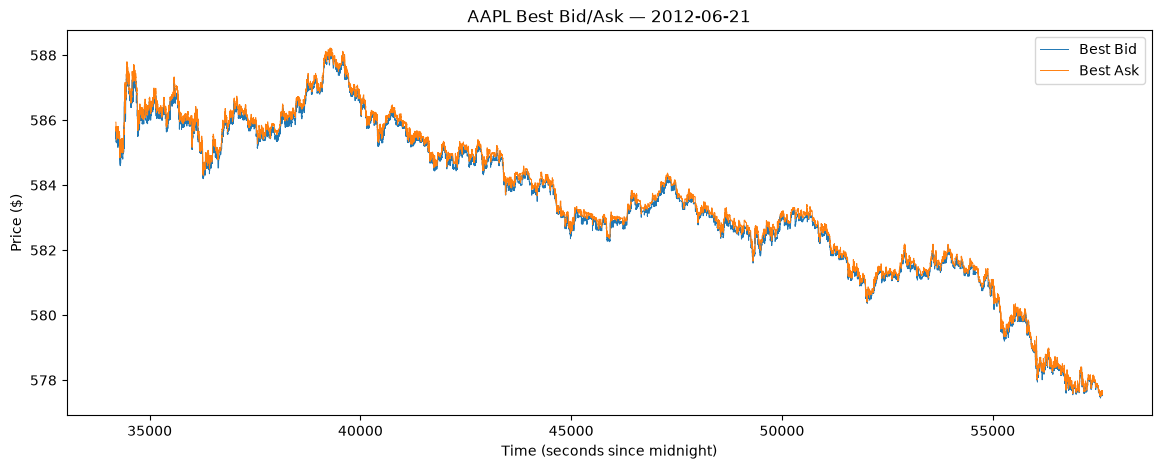

In [4]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df['time'], df['bid_price_1'], label='Best Bid', linewidth=0.7)
ax.plot(df['time'], df['ask_price_1'], label='Best Ask', linewidth=0.7)
ax.set_xlabel('Time (seconds since midnight)')
ax.set_ylabel('Price ($)')
ax.set_title('AAPL Best Bid/Ask — 2012-06-21')
ax.legend()
plt.show()

In [5]:
# Separate new orders and full cancellations
new_orders = df[df['event_label'] == 'new_order'][['order_id', 'time', 'size', 'price', 'direction']]
cancels = df[df['event_label'] == 'full_cancel'][['order_id', 'time']]

# Match each cancellation back to its original order submission
lifetimes = new_orders.merge(cancels, on='order_id', suffixes=('_submit', '_cancel'))
lifetimes['lifetime_sec'] = lifetimes['time_cancel'] - lifetimes['time_submit']

lifetimes[['order_id', 'time_submit', 'time_cancel', 'lifetime_sec', 'size', 'price']].head(10)

,order_id,time_submit,time_cancel,lifetime_sec,size,price
0,16113575,34200.004241,34200.274848,0.270607,18,585.33
1,16113584,34200.004261,34200.201742,0.197482,18,585.32
2,16113594,34200.004447,34200.201736,0.197289,18,585.31
3,16120456,34200.025552,34200.201743,0.176191,18,585.91
4,16120480,34200.025580,34200.201781,0.176201,18,585.92
5,16120503,34200.025613,34200.201768,0.176155,18,585.93
6,16127688,34200.050241,34278.890369,78.840128,100,585.00
7,16166035,34200.201518,34398.237195,198.035677,100,585.93
8,16167159,34200.205573,34200.274847,0.069274,18,585.36
9,16167166,34200.205597,34200.274930,0.069334,18,585.35


In [6]:
print(lifetimes['lifetime_sec'].describe())

count    164962.000000
mean          2.623040
std          16.693231
min           0.000016
25%           0.016788
50%           0.289871
75%           1.595195
max        2945.194745
Name: lifetime_sec, dtype: float64


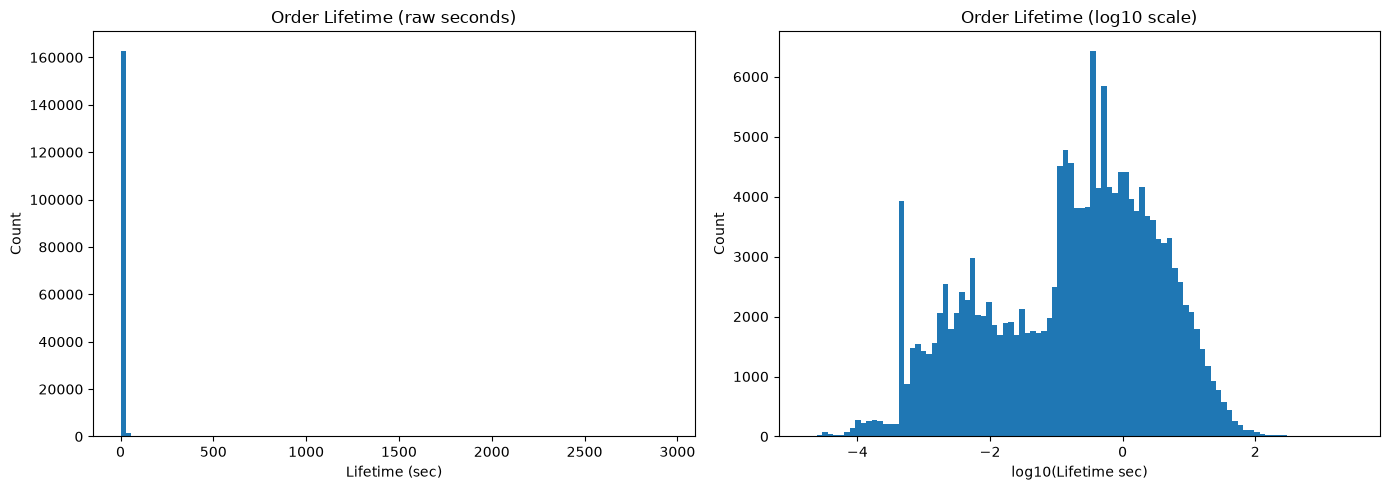

In [7]:
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw histogram
axes[0].hist(lifetimes['lifetime_sec'], bins=100)
axes[0].set_title('Order Lifetime (raw seconds)')
axes[0].set_xlabel('Lifetime (sec)')
axes[0].set_ylabel('Count')

# Log-scale histogram — essential given the skew
axes[1].hist(np.log10(lifetimes['lifetime_sec'] + 1e-6), bins=100)
axes[1].set_title('Order Lifetime (log10 scale)')
axes[1].set_xlabel('log10(Lifetime sec)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

In [8]:
# Look at the exact log10 value where that spike sits
lifetimes['log_lifetime'] = np.log10(lifetimes['lifetime_sec'] + 1e-6)

# Zoom into the region around the spike
spike_region = lifetimes[(lifetimes['log_lifetime'] > -4) & (lifetimes['log_lifetime'] < -3)]
print("Orders in spike region:", len(spike_region))
print(spike_region['lifetime_sec'].describe())

Orders in spike region: 10397
count    10397.000000
mean         0.000554
std          0.000222
min          0.000099
25%          0.000464
50%          0.000484
75%          0.000724
max          0.000999
Name: lifetime_sec, dtype: float64


In [9]:
# What fraction of ALL cancelled orders does this represent?
pct_ultra_fast = (lifetimes['lifetime_sec'] < 0.001).mean() * 100
print(f"% of cancelled orders with lifetime < 1ms: {pct_ultra_fast:.2f}%")

% of cancelled orders with lifetime < 1ms: 6.64%


In [10]:
# --- Feature 1: is_ultra_fast_cancel ---
lifetimes['is_ultra_fast_cancel'] = (lifetimes['lifetime_sec'] < 0.001).astype(int)

lifetimes['is_ultra_fast_cancel'].value_counts()

is_ultra_fast_cancel
0    154013
1     10949
Name: count, dtype: int64

In [11]:
# --- Feature 2: order-to-trade ratio (per time window) ---
# First, count new orders vs executions in fixed time buckets (e.g. every 10 seconds)
df['time_bucket'] = (df['time'] // 10).astype(int)  # 10-second buckets

bucket_counts = df.groupby('time_bucket')['event_label'].value_counts().unstack(fill_value=0)
bucket_counts['order_to_trade_ratio'] = (
    bucket_counts['new_order'] / bucket_counts['visible_execution'].replace(0, 1)
)

bucket_counts[['new_order', 'full_cancel', 'visible_execution', 'order_to_trade_ratio']].head(10)

event_label,new_order,full_cancel,visible_execution,order_to_trade_ratio
time_bucket,,,,
3420,201,126,56,3.589286
3421,62,55,14,4.428571
3422,49,47,2,24.500000
3423,88,84,5,17.600000
3424,76,60,21,3.619048
3425,116,95,17,6.823529
3426,88,86,12,7.333333
3427,93,83,13,7.153846
3428,194,185,86,2.255814


count    2340.000000
mean       17.258832
std        17.240788
min         1.058824
25%         6.666667
50%        11.320513
75%        21.732955
max       169.000000
Name: order_to_trade_ratio, dtype: float64


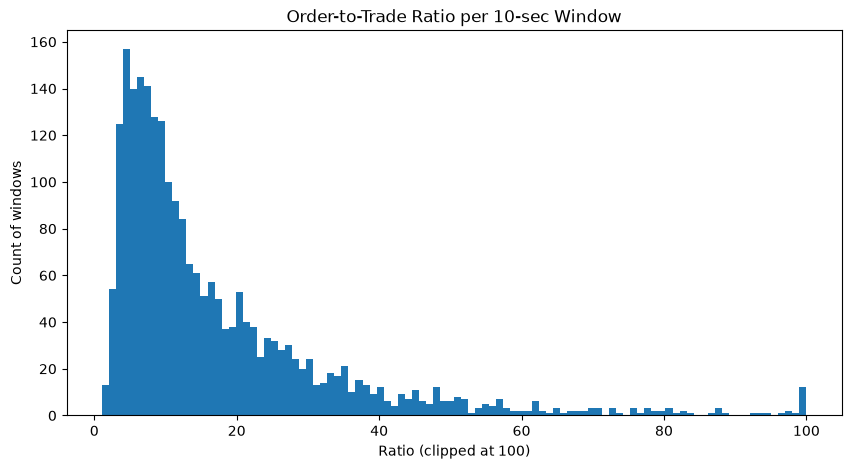

In [12]:
print(bucket_counts['order_to_trade_ratio'].describe())

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(bucket_counts['order_to_trade_ratio'].clip(upper=100), bins=100)
ax.set_title('Order-to-Trade Ratio per 10-sec Window')
ax.set_xlabel('Ratio (clipped at 100)')
ax.set_ylabel('Count of windows')
plt.show()

In [13]:
# Define outlier threshold using a percentile-based rule
threshold_95 = bucket_counts['order_to_trade_ratio'].quantile(0.95)
threshold_99 = bucket_counts['order_to_trade_ratio'].quantile(0.99)
print(f"95th percentile ratio: {threshold_95:.2f}")
print(f"99th percentile ratio: {threshold_99:.2f}")

bucket_counts['is_high_ratio_window'] = (bucket_counts['order_to_trade_ratio'] > threshold_95).astype(int)
bucket_counts['is_high_ratio_window'].sum()

95th percentile ratio: 50.00
99th percentile ratio: 85.83


np.int64(116)

In [14]:
# --- Attach the time_bucket to each order (based on its submission time) ---
lifetimes['time_bucket'] = (lifetimes['time_submit'] // 10).astype(int)

# --- Bring in the window-level ratio + flag for the bucket each order was submitted in ---
features = lifetimes.merge(
    bucket_counts[['order_to_trade_ratio', 'is_high_ratio_window']],
    on='time_bucket',
    how='left'
)

features.head()

,order_id,time_submit,size,price,direction,time_cancel,lifetime_sec,log_lifetime,is_ultra_fast_cancel,time_bucket,order_to_trade_ratio,is_high_ratio_window
0,16113575,34200.004241,18,585.33,1,34200.274848,0.270607,-0.567660,0,3420,3.589286,0
1,16113584,34200.004261,18,585.32,1,34200.201742,0.197482,-0.704471,0,3420,3.589286,0
2,16113594,34200.004447,18,585.31,1,34200.201736,0.197289,-0.704896,0,3420,3.589286,0
3,16120456,34200.025552,18,585.91,-1,34200.201743,0.176191,-0.754013,0,3420,3.589286,0
4,16120480,34200.025580,18,585.92,-1,34200.201781,0.176201,-0.753988,0,3420,3.589286,0


In [15]:
# --- Sanity check: no row duplication from the merge ---
print("Original order count:", len(lifetimes))
print("Post-merge feature count:", len(features))

Original order count: 164962
Post-merge feature count: 164962


In [16]:
# --- First composite signal: does the order show BOTH red flags? ---
features['dual_flag'] = (
    (features['is_ultra_fast_cancel'] == 1) & (features['is_high_ratio_window'] == 1)
).astype(int)

features['dual_flag'].sum()

np.int64(634)

In [17]:
# --- Feature 3: order size relative to average size at that price level ---
avg_size_by_price = df.groupby('price')['size'].transform('mean')
df['size_vs_avg'] = df['size'] / avg_size_by_price

# Bring this into features, matched by order_id (using the original submission row)
size_info = df[df['event_label'] == 'new_order'][['order_id', 'size_vs_avg']]
features = features.merge(size_info, on='order_id', how='left')

features[['order_id', 'size', 'price', 'size_vs_avg']].head()

,order_id,size,price,size_vs_avg
0,16113575,18,585.33,0.246363
1,16113584,18,585.32,0.218595
2,16113594,18,585.31,0.248441
3,16120456,18,585.91,0.264257
4,16120480,18,585.92,0.233304


In [18]:
# --- Feature 4: repeat behavior by order — how many times has THIS trader's pattern repeated? ---
# We don't have trader IDs in LOBSTER (anonymized), so we approximate using price+direction clustering
# Count how many ultra-fast-cancels happened at the same price level (proxy for repeated spoofing at that level)
price_level_fast_cancels = features.groupby('price')['is_ultra_fast_cancel'].transform('sum')
features['fast_cancels_at_this_price'] = price_level_fast_cancels

features[['order_id', 'price', 'is_ultra_fast_cancel', 'fast_cancels_at_this_price']].sort_values(
    'fast_cancels_at_this_price', ascending=False
).head(10)

,order_id,price,is_ultra_fast_cancel,fast_cancels_at_this_price
137349,249040703,579.53,1,102
137347,249040694,579.53,1,102
137376,249040846,579.53,1,102
137346,249040688,579.53,1,102
137368,249040799,579.53,1,102
137367,249040795,579.53,1,102
137365,249040786,579.53,1,102
137364,249040783,579.53,1,102
137362,249040774,579.53,1,102
137361,249040764,579.53,1,102


In [19]:
feature_cols = [
    'lifetime_sec',
    'log_lifetime',
    'is_ultra_fast_cancel',
    'order_to_trade_ratio',
    'is_high_ratio_window',
    'dual_flag',
    'size_vs_avg',
    'fast_cancels_at_this_price'
]

model_df = features[feature_cols].copy()

print(model_df.isna().sum())
print(model_df.shape)

lifetime_sec                  0
log_lifetime                  0
is_ultra_fast_cancel          0
order_to_trade_ratio          0
is_high_ratio_window          0
dual_flag                     0
size_vs_avg                   0
fast_cancels_at_this_price    0
dtype: int64
(164962, 8)


In [20]:
# Fill any missing values sensibly
model_df['order_to_trade_ratio'] = model_df['order_to_trade_ratio'].fillna(model_df['order_to_trade_ratio'].median())
model_df['is_high_ratio_window'] = model_df['is_high_ratio_window'].fillna(0)
model_df['size_vs_avg'] = model_df['size_vs_avg'].fillna(model_df['size_vs_avg'].median())

print(model_df.isna().sum())  # should now all be 0

lifetime_sec                  0
log_lifetime                  0
is_ultra_fast_cancel          0
order_to_trade_ratio          0
is_high_ratio_window          0
dual_flag                     0
size_vs_avg                   0
fast_cancels_at_this_price    0
dtype: int64


In [21]:
# Define outlier threshold using a percentile-based rule
threshold_95 = bucket_counts['order_to_trade_ratio'].quantile(0.95)
threshold_99 = bucket_counts['order_to_trade_ratio'].quantile(0.99)
print(f"95th percentile ratio: {threshold_95:.2f}")
print(f"99th percentile ratio: {threshold_99:.2f}")

bucket_counts['is_high_ratio_window'] = (bucket_counts['order_to_trade_ratio'] > threshold_95).astype(int)
bucket_counts['is_high_ratio_window'].sum()

95th percentile ratio: 50.00
99th percentile ratio: 85.83


np.int64(116)

Training the Isolation Forest

In [22]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
import pandas as pd

# --- Scale features ---
# Isolation Forest is fairly robust to scale, but StandardScaler still helps
# when features have wildly different ranges (e.g. lifetime_sec vs is_ultra_fast_cancel)
scaler = StandardScaler()
X = scaler.fit_transform(model_df)

# --- Train the model ---
iso_forest = IsolationForest(
    n_estimators=200,      # number of random trees
    contamination=0.05,    # our assumed % of anomalies — matches our earlier ~5-6% baseline
    random_state=42,
    n_jobs=-1              # use all CPU cores
)

iso_forest.fit(X)

# --- Get anomaly scores and predictions ---
model_df['anomaly_score'] = iso_forest.decision_function(X)  # higher = more normal
model_df['is_anomaly'] = iso_forest.predict(X)                # -1 = anomaly, 1 = normal

model_df['is_anomaly'].value_counts()

is_anomaly
 1    156713
-1      8249
Name: count, dtype: int64

In [23]:
# --- Cross-check: do our rule-based flags agree with the model? ---
crosstab = pd.crosstab(model_df['is_anomaly'], model_df['dual_flag'])
print(crosstab)

dual_flag        0    1
is_anomaly             
-1            7615  634
 1          156713    0


 Visualizing Anomalies on the Price Chart

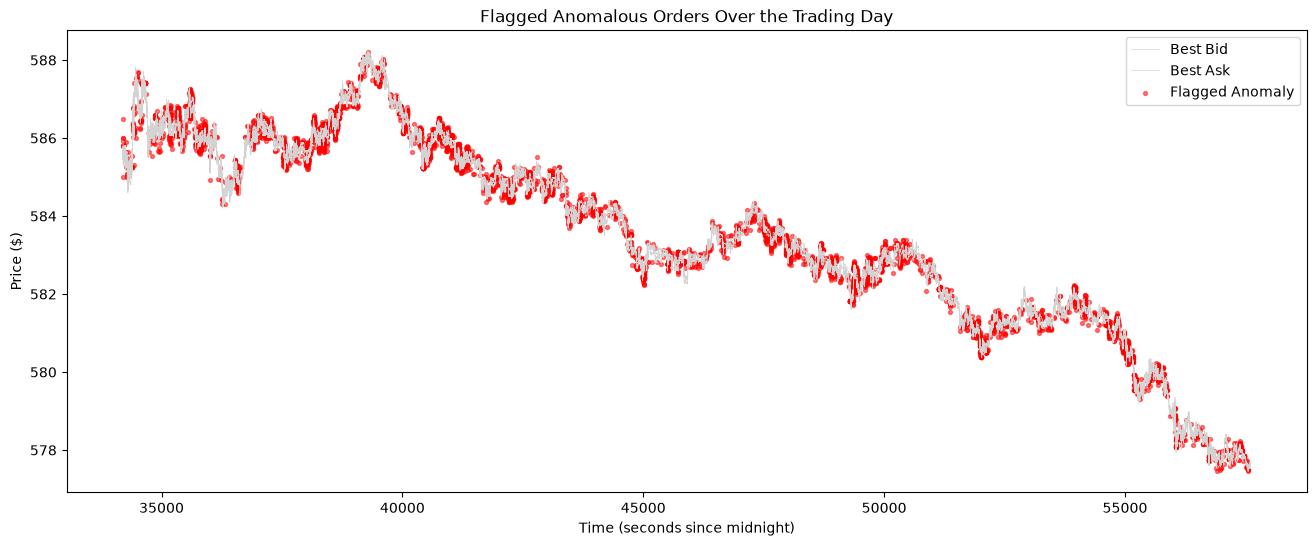

In [24]:
# Bring timestamps back in for plotting
plot_df = features[['time_submit', 'price']].copy()
plot_df['is_anomaly'] = model_df['is_anomaly'].values

fig, ax = plt.subplots(figsize=(16, 6))

# Plot the overall best bid/ask as background context
ax.plot(df['time'], df['bid_price_1'], color='lightgray', linewidth=0.5, label='Best Bid')
ax.plot(df['time'], df['ask_price_1'], color='lightgray', linewidth=0.5, label='Best Ask')

# Overlay flagged anomalous orders as red dots
anomalies = plot_df[plot_df['is_anomaly'] == -1]
ax.scatter(anomalies['time_submit'], anomalies['price'], color='red', s=8, alpha=0.5, label='Flagged Anomaly')

ax.set_xlabel('Time (seconds since midnight)')
ax.set_ylabel('Price ($)')
ax.set_title('Flagged Anomalous Orders Over the Trading Day')
ax.legend()
plt.show()

Checking Temporal Clustering Directly

count    2340.000000
mean        0.043218
std         0.133983
min         0.000000
25%         0.000000
50%         0.000000
75%         0.025424
max         1.000000
dtype: float64


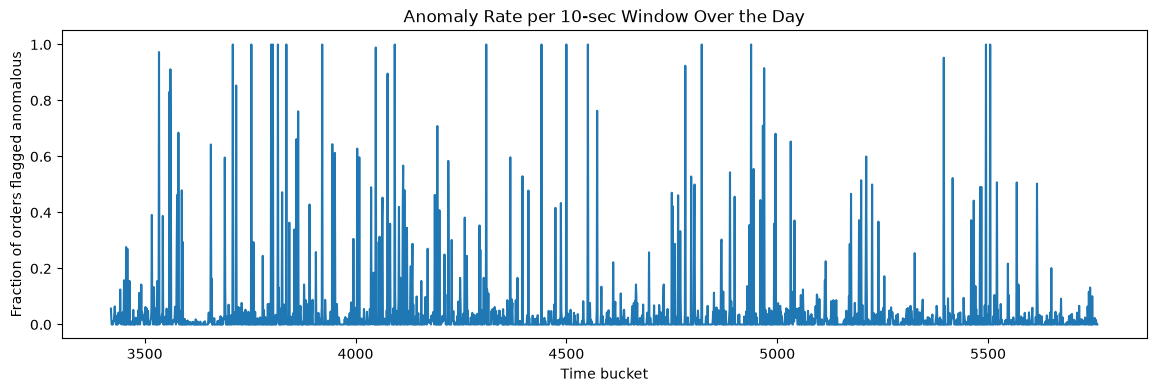

In [25]:
# Do flagged anomalies cluster in TIME more than random chance would suggest?
plot_df['time_bucket'] = (plot_df['time_submit'] // 10).astype(int)

anomalies_per_bucket = plot_df.groupby('time_bucket')['is_anomaly'].apply(lambda x: (x == -1).sum())
total_per_bucket = plot_df.groupby('time_bucket').size()

anomaly_rate_per_bucket = (anomalies_per_bucket / total_per_bucket).fillna(0)

print(anomaly_rate_per_bucket.describe())

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(anomaly_rate_per_bucket.index, anomaly_rate_per_bucket.values)
ax.set_title('Anomaly Rate per 10-sec Window Over the Day')
ax.set_xlabel('Time bucket')
ax.set_ylabel('Fraction of orders flagged anomalous')
plt.show()

Case Study — Zooming Into the Biggest Spike

In [26]:
# Find the time bucket with the highest anomaly rate (among buckets with meaningful volume)
candidate_buckets = anomaly_rate_per_bucket[total_per_bucket >= 5]  # ignore buckets with too few orders to be meaningful
worst_bucket = candidate_buckets.idxmax()
print(f"Worst bucket: {worst_bucket}, anomaly rate: {candidate_buckets[worst_bucket]:.2%}, total orders: {total_per_bucket[worst_bucket]}")

# Pull out everything that happened in that 10-second window
window_start = worst_bucket * 10
window_end = window_start + 10

case_study = df[(df['time'] >= window_start) & (df['time'] < window_end)].copy()
case_study[['time', 'event_label', 'order_id', 'size', 'price', 'direction', 'bid_price_1', 'ask_price_1']]

Worst bucket: 3709, anomaly rate: 100.00%, total orders: 156


,time,event_label,order_id,size,price,direction,bid_price_1,ask_price_1
62980,37090.845551,new_order,65710491,100,586.09,1,586.32,586.35
62981,37091.117499,new_order,65712338,100,586.30,1,586.32,586.35
62982,37091.546523,new_order,65715036,1400,586.56,-1,586.32,586.35
62983,37091.897444,new_order,65717353,100,586.54,-1,586.32,586.35
62984,37091.965443,new_order,65718153,100,586.10,1,586.32,586.35
...,...,...,...,...,...,...,...,...
63320,37099.998840,new_order,65771659,100,586.45,-1,586.32,586.43
63321,37099.998887,full_cancel,65771578,200,586.46,-1,586.32,586.43
63322,37099.998889,full_cancel,65771579,100,586.46,-1,586.32,586.43
63323,37099.999583,full_cancel,65771659,100,586.45,-1,586.32,586.43


 Quantifying This Specific Incident

In [27]:
# How many orders in this window were ultra-fast-cancelled?
case_orders = case_study[case_study['event_label'] == 'new_order']['order_id']
window_lifetimes = lifetimes[lifetimes['order_id'].isin(case_orders)]

print("Orders in window with a matched cancel:", len(window_lifetimes))
print(window_lifetimes['lifetime_sec'].describe())
print("\nUltra-fast cancels in this window:", window_lifetimes['is_ultra_fast_cancel'].sum())

# Order-to-trade ratio for this specific window
n_new = (case_study['event_label'] == 'new_order').sum()
n_exec = (case_study['event_label'] == 'visible_execution').sum()
print(f"\nNew orders: {n_new}, Executions: {n_exec}, Order-to-trade ratio: {n_new / max(n_exec,1):.1f}")

Orders in window with a matched cancel: 156
count    156.000000
mean       3.038888
std       20.470201
min        0.000467
25%        0.000930
50%        0.029033
75%        0.031791
max      180.664729
Name: lifetime_sec, dtype: float64

Ultra-fast cancels in this window: 72

New orders: 158, Executions: 1, Order-to-trade ratio: 158.0


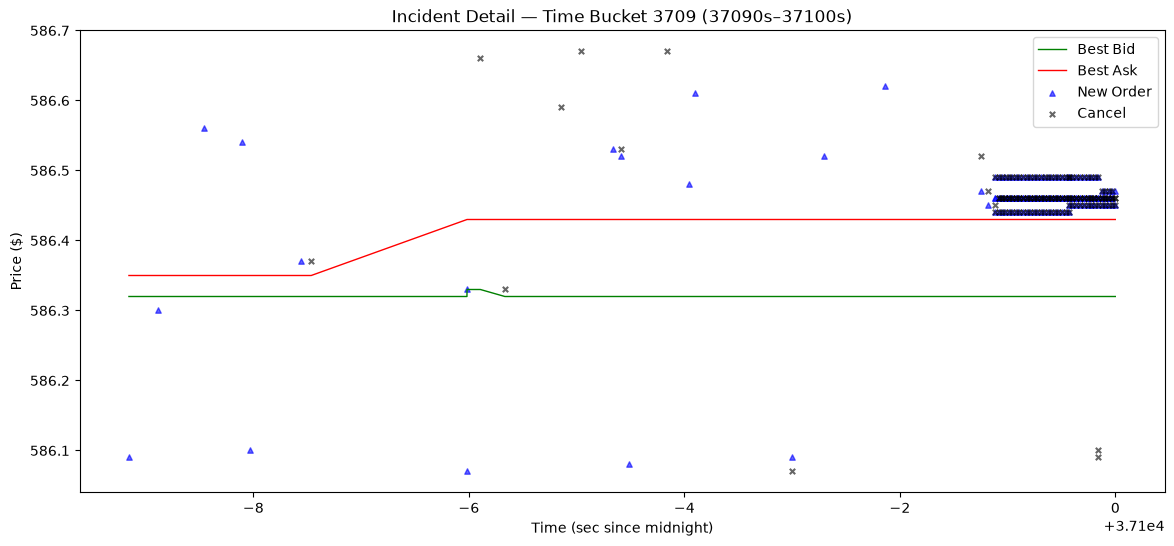

In [28]:
# Visualize just this window: price action + every event marked
fig, ax = plt.subplots(figsize=(14, 6))

window_book = df[(df['time'] >= window_start) & (df['time'] < window_end)]
ax.plot(window_book['time'], window_book['bid_price_1'], label='Best Bid', color='green', linewidth=1)
ax.plot(window_book['time'], window_book['ask_price_1'], label='Best Ask', color='red', linewidth=1)

new_orders_in_window = case_study[case_study['event_label'] == 'new_order']
cancels_in_window = case_study[case_study['event_label'] == 'full_cancel']

ax.scatter(new_orders_in_window['time'], new_orders_in_window['price'], color='blue', s=15, alpha=0.6, label='New Order', marker='^')
ax.scatter(cancels_in_window['time'], cancels_in_window['price'], color='black', s=15, alpha=0.6, label='Cancel', marker='x')

ax.set_xlabel('Time (sec since midnight)')
ax.set_ylabel('Price ($)')
ax.set_title(f'Incident Detail — Time Bucket {worst_bucket} ({window_start}s–{window_end}s)')
ax.legend()
plt.show()

Injecting Synthetic Spoofing Patterns

In [29]:
import numpy as np

np.random.seed(42)  # reproducibility

def generate_synthetic_spoofing_episodes(df, n_episodes=200, orders_per_episode_range=(3, 8)):
    """
    Generates synthetic spoofing episodes by sampling real moments in the day
    and creating fabricated order sequences around them.
    """
    synthetic_orders = []
    
    # Pick random real timestamps to anchor each episode
    anchor_times = np.random.choice(df['time'].values, size=n_episodes, replace=False)
    
    for episode_id, anchor_time in enumerate(anchor_times):
        # Find the real book state at this moment to place realistic prices
        nearest_idx = (df['time'] - anchor_time).abs().idxmin()
        ref_row = df.loc[nearest_idx]
        best_bid = ref_row['bid_price_1']
        best_ask = ref_row['ask_price_1']
        
        n_orders = np.random.randint(*orders_per_episode_range)
        
        for i in range(n_orders):
            # Place order slightly away from touch (mimicking layering behavior)
            direction = np.random.choice([1, -1])
            price_offset = np.random.uniform(0.01, 0.10)  # a few cents away from touch
            price = (best_ask + price_offset) if direction == -1 else (best_bid - price_offset)
            
            size = np.random.randint(100, 500)  # larger than typical order size
            submit_time = anchor_time + i * 0.001  # stagger submissions by ~1ms
            lifetime = np.random.uniform(0.0002, 0.003)  # 0.2ms to 3ms, mimicking our case study
            
            synthetic_orders.append({
                'episode_id': episode_id,
                'time_submit': submit_time,
                'time_cancel': submit_time + lifetime,
                'lifetime_sec': lifetime,
                'size': size,
                'price': price,
                'direction': direction,
                'label': 1  # synthetic spoofing
            })
    
    return pd.DataFrame(synthetic_orders)

synthetic_df = generate_synthetic_spoofing_episodes(df, n_episodes=200)
print(synthetic_df.shape)
synthetic_df.head(10)

(987, 8)


,episode_id,time_submit,time_cancel,lifetime_sec,size,price,direction,label
0,0,52894.011363,52894.012009,0.000647,322,581.810824,1,1
1,0,52894.012363,52894.012653,0.000290,340,581.769876,1,1
2,0,52894.013363,52894.014088,0.000725,379,581.801304,1,1
3,1,55438.802545,55438.804883,0.002338,215,579.750293,1,1
4,1,55438.803545,55438.804840,0.001295,199,579.749953,1,1
5,1,55438.804545,55438.806505,0.001960,147,579.735114,1,1
6,2,36255.118530,36255.120354,0.001824,464,584.793560,1,1
7,2,36255.119530,36255.121009,0.001480,379,584.814895,1,1
8,2,36255.120530,36255.122954,0.002424,344,584.814733,1,1
9,2,36255.121530,36255.123817,0.002287,283,584.792846,1,1


In [30]:
synthetic_df['direction'].value_counts()

direction
 1    495
-1    492
Name: count, dtype: int64

Merging Synthetic + Real Data, Rebuilding Features with Labels

In [31]:
# --- Combine real orders (label=0) with synthetic spoofing orders (label=1) ---

# Real orders: reuse our earlier `lifetimes` dataframe, just add a label column
real_labeled = lifetimes[['order_id', 'time_submit', 'time_cancel', 'lifetime_sec', 'size', 'price', 'direction']].copy()
real_labeled['label'] = 0
real_labeled['episode_id'] = -1  # -1 marks "not synthetic"

# Synthetic orders: assign fake order_ids that don't collide with real ones
synthetic_df['order_id'] = -(synthetic_df.index + 1)  # negative IDs guarantee no overlap with real (positive) order_ids

# Combine
combined = pd.concat([real_labeled, synthetic_df[real_labeled.columns]], ignore_index=True)

print(combined.shape)
print(combined['label'].value_counts())

(165949, 9)
label
0    164962
1       987
Name: count, dtype: int64


Rebuilding Features on the Combined Dataset

In [32]:
# --- Feature 1: is_ultra_fast_cancel (same logic as before) ---
combined['is_ultra_fast_cancel'] = (combined['lifetime_sec'] < 0.001).astype(int)

# --- Feature 2: order_to_trade_ratio + is_high_ratio_window ---
# Assign time buckets using the same 10-second window logic
combined['time_bucket'] = (combined['time_submit'] // 10).astype(int)

# Reuse the REAL order-to-trade ratios computed earlier from bucket_counts (based on real market activity)
# Synthetic orders inherit the ratio of whichever real window they were anchored to
combined = combined.merge(
    bucket_counts[['order_to_trade_ratio', 'is_high_ratio_window']],
    on='time_bucket',
    how='left'
)
combined['order_to_trade_ratio'] = combined['order_to_trade_ratio'].fillna(combined['order_to_trade_ratio'].median())
combined['is_high_ratio_window'] = combined['is_high_ratio_window'].fillna(0)

# --- Feature 3: dual_flag ---
combined['dual_flag'] = ((combined['is_ultra_fast_cancel'] == 1) & (combined['is_high_ratio_window'] == 1)).astype(int)

print(combined.shape)
combined[['order_id', 'label', 'is_ultra_fast_cancel', 'order_to_trade_ratio', 'is_high_ratio_window', 'dual_flag']].tail(10)

(165949, 14)


,order_id,label,is_ultra_fast_cancel,order_to_trade_ratio,is_high_ratio_window,dual_flag
165939,-978,1,0,6.545455,0,0
165940,-979,1,0,6.545455,0,0
165941,-980,1,1,6.545455,0,0
165942,-981,1,1,6.444444,0,0
165943,-982,1,0,6.444444,0,0
165944,-983,1,0,6.444444,0,0
165945,-984,1,1,6.444444,0,0
165946,-985,1,0,6.444444,0,0
165947,-986,1,0,6.444444,0,0
165948,-987,1,0,6.444444,0,0


In [33]:
# --- Feature 4: size_vs_avg ---
# Need average size by price from REAL data (already computed earlier as avg_size_by_price via df)
price_avg_size_map = df.groupby('price')['size'].mean()

# Map each combined order's price to the nearest real price level's average size
def get_avg_size_for_price(price):
    idx = (price_avg_size_map.index - price).abs().argmin()
    return price_avg_size_map.iloc[idx]

# This is a bit slow row-by-row, so we vectorize using searchsorted for speed
sorted_prices = np.sort(price_avg_size_map.index.values)
nearest_idx = np.searchsorted(sorted_prices, combined['price'].values)
nearest_idx = np.clip(nearest_idx, 0, len(sorted_prices) - 1)
combined['nearest_price_level'] = sorted_prices[nearest_idx]
combined = combined.merge(
    price_avg_size_map.rename('avg_size_at_price').reset_index().rename(columns={'price': 'nearest_price_level'}),
    on='nearest_price_level', how='left'
)
combined['size_vs_avg'] = combined['size'] / combined['avg_size_at_price']

# --- Feature 5: fast_cancels_at_this_price ---
combined['fast_cancels_at_this_price'] = combined.groupby('nearest_price_level')['is_ultra_fast_cancel'].transform('sum')

# --- Feature 6: log_lifetime ---
combined['log_lifetime'] = np.log10(combined['lifetime_sec'] + 1e-6)

print(combined.shape)
combined[combined['label']==1][['order_id', 'price', 'size', 'size_vs_avg', 'fast_cancels_at_this_price']].head(10)

(165949, 19)


,order_id,price,size,size_vs_avg,fast_cancels_at_this_price
164962,-1,581.810824,322,3.605190,35
164963,-2,581.769876,340,3.915966,6
164964,-3,581.801304,379,4.691824,20
164965,-4,579.750293,215,2.399016,22
164966,-5,579.749953,199,2.021424,15
164967,-6,579.735114,147,1.438666,24
164968,-7,584.793560,464,5.454019,6
164969,-8,584.814895,379,4.355212,10
164970,-9,584.814733,344,3.953015,10
164971,-10,584.792846,283,3.326481,6


Training XGBoost with Class Weighting

In [34]:
X = combined[FEATURE_COLUMNS].fillna(combined[FEATURE_COLUMNS].median())
y = combined['label']

xgb_model, X_test, y_test, y_pred, y_proba, report, pr_auc = train_xgboost_classifier(X, y)

print(report)
print(f"PR-AUC: {pr_auc:.4f}")

                    precision    recall  f1-score   support

              Real       1.00      1.00      1.00     49489
Synthetic Spoofing       0.49      0.78      0.61       296

          accuracy                           0.99     49785
         macro avg       0.75      0.89      0.80     49785
      weighted avg       1.00      0.99      0.99     49785

PR-AUC: 0.7428


In [35]:
model_features_combined = combined[FEATURE_COLUMNS].fillna(combined[FEATURE_COLUMNS].median())

iso_forest2, scaler2, X_full_scaled = train_isolation_forest(model_features_combined, contamination=0.05)
iso_anomaly_score, iso_anomaly = score_isolation_forest(iso_forest2, X_full_scaled)

combined['iso_anomaly'] = iso_anomaly
combined['iso_anomaly_flag'] = (combined['iso_anomaly'] == -1).astype(int)

synthetic_mask = combined['label'] == 1
iso_recall = combined.loc[synthetic_mask, 'iso_anomaly_flag'].mean()
print(f"Isolation Forest recall on synthetic spoofing: {iso_recall:.2%}")

flagged_mask = combined['iso_anomaly_flag'] == 1
iso_precision = combined.loc[flagged_mask, 'label'].mean()
print(f"Isolation Forest precision on flagged orders: {iso_precision:.2%}")

Isolation Forest recall on synthetic spoofing: 20.87%
Isolation Forest precision on flagged orders: 2.48%


Head-to-Head Comparison — XGBoost vs Isolation Forest

In [36]:
from sklearn.metrics import precision_score, recall_score

xgb_recall = recall_score(y_test, y_pred)
xgb_precision = precision_score(y_test, y_pred)

comparison = pd.DataFrame({
    'Model': ['XGBoost (supervised)', 'Isolation Forest (unsupervised)'],
    'Recall on Spoofing': [xgb_recall, iso_recall],
    'Precision on Spoofing': [xgb_precision, iso_precision],
})
comparison

,Model,Recall on Spoofing,Precision on Spoofing
0,XGBoost (supervised),0.783784,0.494670
1,Isolation Forest (unsupervised),0.208713,0.024828


Feature Importance Analysis

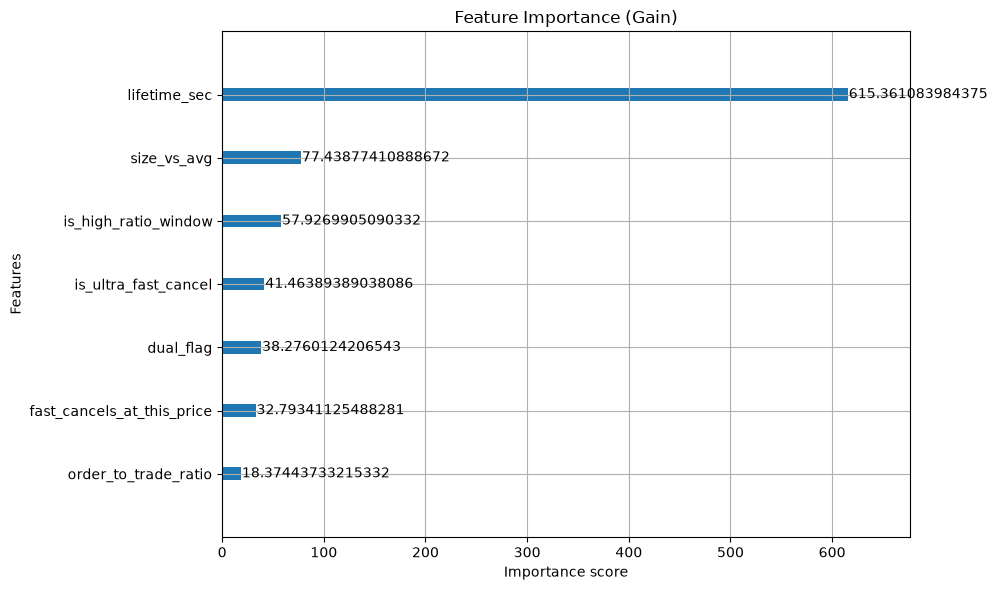

In [37]:
import matplotlib.pyplot as plt
from xgboost import plot_importance

# --- Method 1: XGBoost's built-in importance (gain-based) ---
fig, ax = plt.subplots(figsize=(10, 6))
plot_importance(xgb_model, importance_type='gain', ax=ax, max_num_features=8)
ax.set_title('Feature Importance (Gain)')
plt.tight_layout()
plt.show()

C:\Users\abbas\AppData\Local\Temp\ipykernel_15072\3485493867.py:7: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, plot_type='bar', show=False)


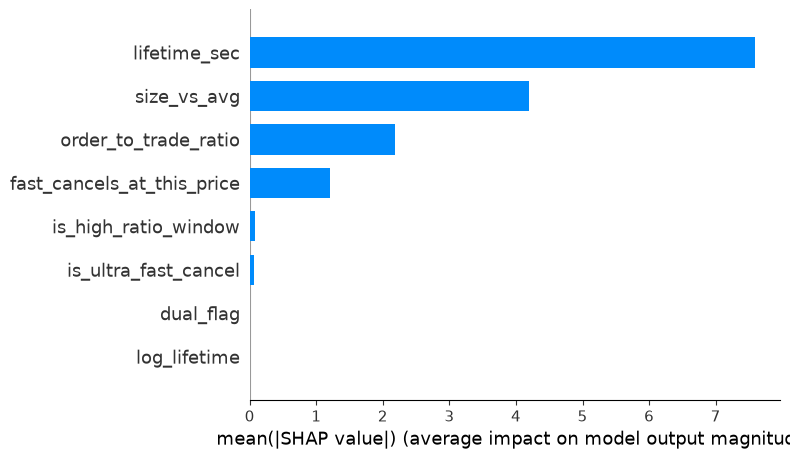

In [38]:
# --- Method 2: SHAP values (more rigorous, shows direction + interaction) ---
import shap

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, plot_type='bar', show=False)
plt.tight_layout()
plt.savefig('shap_importance.png')
plt.show()

C:\Users\abbas\AppData\Local\Temp\ipykernel_15072\2787156550.py:2: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, show=False)


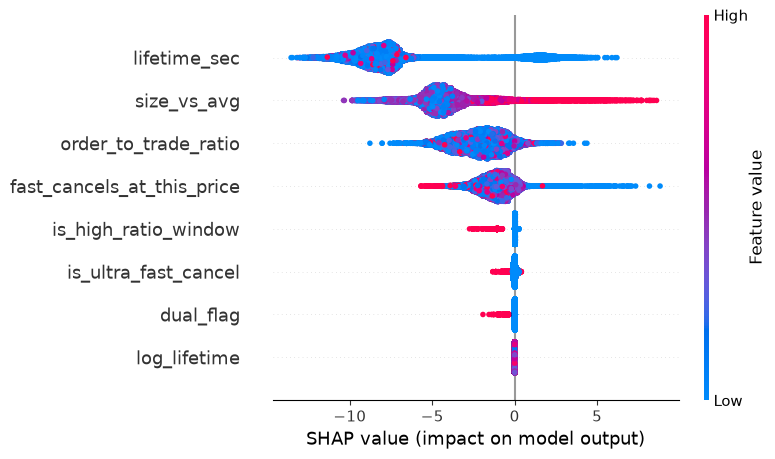

In [39]:
# --- Method 3: a detailed summary plot showing direction per feature ---
shap.summary_plot(shap_values, X_test, show=False)
plt.tight_layout()
plt.savefig('shap_summary_detailed.png')
plt.show()

In [40]:
import os
os.makedirs('../data/processed', exist_ok=True)

# Save using pickle instead of parquet — avoids the pyarrow extension-type conflict
df.to_pickle('../data/processed/full_events.pkl')
combined.to_pickle('../data/processed/features_labeled.pkl')
model_df[['anomaly_score', 'is_anomaly']].to_pickle('../data/processed/iso_forest_results.pkl')

import json
comparison_dict = {
    'xgboost': {'recall': 0.78, 'precision': 0.49},
    'isolation_forest': {'recall': float(iso_recall), 'precision': float(iso_precision)}
}
with open('../data/processed/model_comparison.json', 'w') as f:
    json.dump(comparison_dict, f)

print("Saved successfully")

Saved successfully
